In [6]:
import pandas as pd
import numpy as np
import sys
import glob
import math
import matplotlib.pyplot as plt

from src.utils import (
    get_valid_dir,
    set_seed,
    get_linear_predictions,
    get_knn_predictions,
    get_embs,
    is_subset,
    process_data_loader,
    print_metrics_in_latex,
    calculate_metrics,
    get_checkpoint_paths,
    mergekfold_results,
    save_normalized_conf_matrices,
    plot_pred_vs_true,
    get_class_dependent_predictions,
    generate_radar_plots,
    filter_classes,
    get_mlp_predictions,
)

from src.models_multimodal import (
    load_model,
)

In [29]:
#read in individual object predictions from evaluate_models_single output
preds_df = pd.read_csv('./multipeak-finetune-noweights-cFrF+MLP+two_single_objs.csv')

#read in dataset dsecription
dataset = pd.read_csv('./data/test/all/ZTFBTS_TransientTable.csv')

In [30]:
# creating placeholder column for the k-fold for which the obj belongs to the validation set for
preds_df['kfold_for_val'] = [0]*len(preds_df)

In [98]:
pd.set_option('display.max_rows',200)
preds_df

,SN,true_label,prediction,modality,kfold_of_pred,kfold_for_val,type
0,ZTF20aahggbm_2,0,0,lightcurve,0,0,SN Ic
1,ZTF20aahggbm_2,0,0,spectral,0,0,SN Ic
2,ZTF20aahggbm_2,0,0,lightcurveandspectral,0,0,SN Ic
3,ZTF20aaiftgi_0,0,0,lightcurve,0,0,SN Ic
4,ZTF20aaiftgi_0,0,0,spectral,0,0,SN Ic
...,...,...,...,...,...,...,...
445,ZTF20aalrqbu_3,1,1,spectral,4,4,SN Ibn
446,ZTF20aalrqbu_3,1,0,lightcurveandspectral,4,4,SN Ibn
447,ZTF20aalrqbu_4,1,0,lightcurve,4,4,SN Ibn
448,ZTF20aalrqbu_4,1,0,spectral,4,4,SN Ibn


In [32]:
#loading in models and validation sets

directories = [
    "models/multipeak-finetune-noweights-cFrF",
]  
names = [
    "multipeak-finetune-noweights-cFrF",
]
models = []

paths = []
ids = []
labels = []
# Finding all checkpoints
for id, (directory, label) in enumerate(zip(directories, names)):
    paths_to_checkpoint, name, id = get_checkpoint_paths(directory, label, id)
    paths.extend(paths_to_checkpoint)
    ids.extend(id)
    labels.extend(name)

for i, path in enumerate(paths):
    print(f"loading {labels[i]}")
    # print(path)
    models.append(load_model(path))

loading multipeak-finetune-noweights-cFrF
loading multipeak-finetune-noweights-cFrF
loading multipeak-finetune-noweights-cFrF
loading multipeak-finetune-noweights-cFrF
loading multipeak-finetune-noweights-cFrF


In [33]:
# if obj appears in list of val_filenames from model, then update k-fold_in_valid to the model i we are on

for i in range(len(models)):
    val_filenames = models[i][-1]
    preds_df.loc[preds_df['SN'].isin(val_filenames), 'kfold_for_val'] = i

In [ ]:
correct = (preds_df['true_label']==preds_df['prediction'])
incorrect = ~correct

In [ ]:
#cross-matching objects between DFs to add SN type to preds_df
types = []
for i,sn in enumerate(preds_df['SN'][::3]):
    sn_ztf = sn[:12]
    snt = dataset.loc[dataset.ZTFID==sn_ztf, 'type'].iloc[0]
    types.append([snt]*3)

preds_df['type'] = np.array(types).flatten()

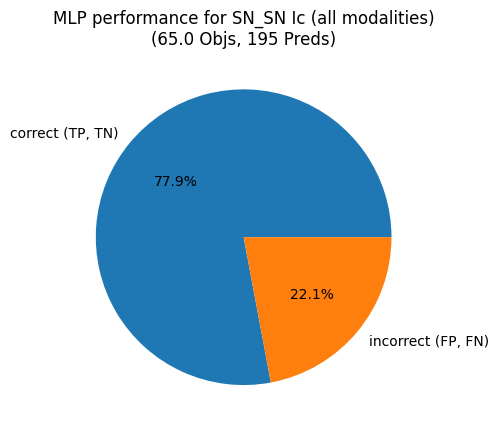

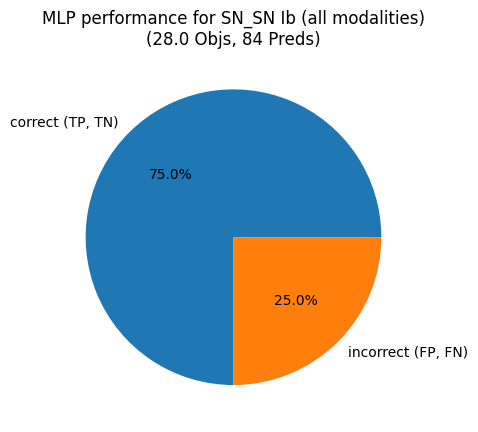

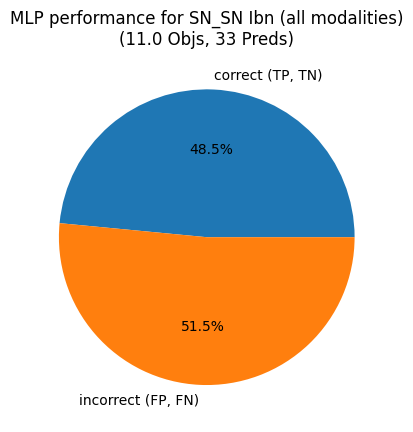

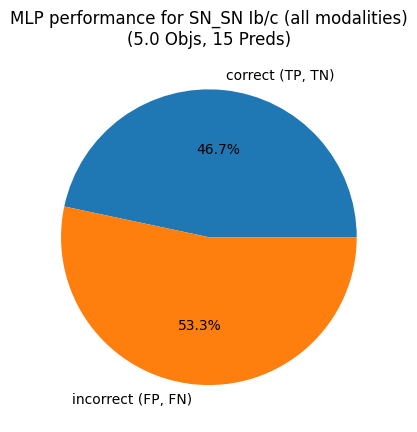

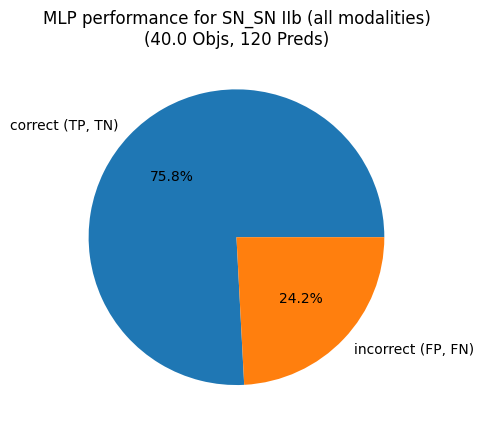

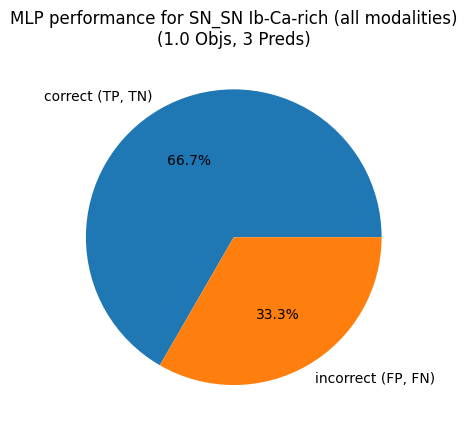

In [99]:
sn_types = preds_df.type.unique()

%matplotlib inline
for i,snt in enumerate(sn_types):
    fig, ax = plt.subplots()
    percents = [len(preds_df.loc[correct&(preds_df['type']==snt)])/len(preds_df.loc[preds_df['type']==snt]),
                len(preds_df.loc[incorrect&(preds_df['type']==snt)])/len(preds_df.loc[preds_df['type']==snt])]
    ax.pie(percents, labels=['correct (TP, TN)', 'incorrect (FP, FN)'], autopct='%1.1f%%')
    ax.set_title(f'MLP performance for SN_{snt} (all modalities)\n({len(preds_df.loc[preds_df['type']==snt])/3} Objs, {len(preds_df.loc[preds_df['type']==snt])} Preds)')
    if snt != 'SN Ib/c':
        plt.savefig(f'./figures/MLP_SN{snt[3:]}_piechart.png', dpi=300)
    else:
        plt.savefig(f'./figures/MLP_SNIbc_piechart.png', dpi=300)
    plt.show()